# Weak Lensing Statistics Visualization

This notebook visualizes all statistics computed from the `compute_all_stats.py` pipeline for weak lensing convergence maps.

**Statistics included:**
1. **Power Spectrum** $P(k)$ - 2D density field
2. **Angular Power Spectrum** $C_\ell$ - convergence maps
3. **Peak Counts** - local maxima distribution
4. **Minima Counts** - local minima distribution  
5. **PDF** - pixel value distribution
6. **Minkowski Functionals** - $V_0$, $V_1$, $V_2$
7. **Wavelet Scattering Transform** - $S_0$, $S_1$
8. **Bispectrum** - equilateral, squeezed, folded, isosceles configurations

In [17]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14

# Paths
STATS_BASE = Path('/mnt/home/mlee1/ceph/hydro_replace_stats')

# Choose model to visualize
MODEL = 'dmo'  # or 'hydro' or a replace model
stats_file = STATS_BASE / MODEL / 'stats.h5'

print(f"Loading statistics from: {stats_file}")
print(f"File exists: {stats_file.exists()}")

Loading statistics from: /mnt/home/mlee1/ceph/hydro_replace_stats/dmo/stats.h5
File exists: True


In [18]:
# Load all statistics
with h5py.File(stats_file, 'r') as f:
    print("Available datasets:")
    for key in f.keys():
        if isinstance(f[key], h5py.Dataset):
            print(f"  {key}: {f[key].shape}")
    
    print("\nAttributes:")
    for attr in f.attrs:
        print(f"  {attr}: {f.attrs[attr]}")
    
    # Load datasets
    data = {}
    for key in f.keys():
        if isinstance(f[key], h5py.Dataset):
            data[key] = f[key][:]
    
    # Load attributes
    attrs = dict(f.attrs)

# Extract useful info
source_z = attrs.get('source_redshifts', [0.5, 1.0, 2.0, 2.5])
z_labels = [f'z={z:.2f}' for z in source_z]
print(f"\nSource redshifts: {source_z}")

Available datasets:
  Cl: (2000, 4, 724)
  Pk: (20, 40, 2896)
  S0: (2000, 4, 3)
  S1: (2000, 4, 5, 3)
  V0: (2000, 4, 51)
  V1: (2000, 4, 51)
  V2: (2000, 4, 51)
  bispec_ell: (14,)
  bispec_equilateral: (2000, 4, 14)
  bispec_folded: (2000, 4, 14)
  bispec_isosceles: (2000, 4, 14)
  bispec_squeezed: (2000, 4, 14)
  ell_bins: (724,)
  k_bins: (2896,)
  mf_thresholds: (51,)
  minima: (2000, 4, 50)
  pdf: (2000, 4, 50)
  peaks: (2000, 4, 50)
  sn_bin_edges: (51,)
  wst_moments: (3,)
  wst_scales: (5,)

Attributes:
  BOX_SIZE: 205.0
  FOV_DEG: 5.0
  N_LP: 20
  N_RUNS: 100
  WST_J: 5
  WST_Q: 1
  bispec_configs: ['equilateral' 'squeezed' 'folded' 'isosceles']
  kappa_targets: [13 23 36 40]
  model: dmo
  smoothing_arcmin: 2.5
  snapshot_order: [96 90 85 80 76 71 67 63 59 56 52 49 46 43 41 38 35 33 31 29]
  snapshot_redshifts: [0.04 0.15 0.27 0.4  0.5  0.64 0.78 0.93 1.07 1.18 1.36 1.5  1.65 1.82
 1.93 2.12 2.32 2.49 2.68 2.87]
  source_redshifts: [0.506 1.034 2.094 2.568]

Source redshift

---
## 1. Power Spectrum $P(k)$

The 2D matter power spectrum measures the amplitude of density fluctuations as a function of wavenumber $k$:

$$P(k) = \langle |\tilde{\delta}(\mathbf{k})|^2 \rangle$$

where $\tilde{\delta}(\mathbf{k})$ is the Fourier transform of the overdensity field:

$$\delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \bar{\rho}}{\bar{\rho}}$$

The power spectrum is computed from lensplanes (projected density fields) and averaged over azimuthal angles in $k$-space.

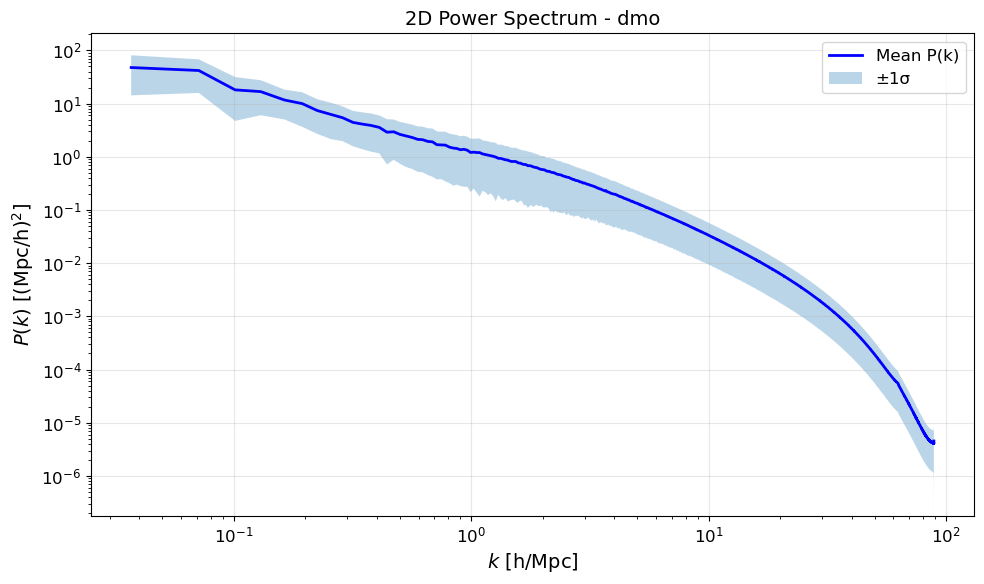

P(k) shape: (20, 40, 2896) (N_LP, N_planes, N_k)


In [19]:
# Plot P(k) from lensplanes
if 'Pk' in data and 'k_bins' in data:
    Pk = data['Pk']  # Shape: (N_LP, N_planes, N_k)
    k = data['k_bins']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Average over all LP orientations and a few planes
    Pk_mean = np.nanmean(Pk, axis=(0, 1))
    Pk_std = np.nanstd(Pk, axis=(0, 1))
    
    ax.loglog(k, Pk_mean, 'b-', lw=2, label='Mean P(k)')
    ax.fill_between(k, Pk_mean - Pk_std, Pk_mean + Pk_std, alpha=0.3, label='±1σ')
    
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P(k)$ [(Mpc/h)$^2$]')
    ax.set_title(f'2D Power Spectrum - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"P(k) shape: {Pk.shape} (N_LP, N_planes, N_k)")
else:
    print("P(k) data not available")

---
## 2. Angular Power Spectrum $C_\ell$

The angular power spectrum describes the variance of the convergence field as a function of multipole $\ell$:

$$C_\ell = \langle |\tilde{\kappa}_{\ell m}|^2 \rangle$$

For a flat-sky approximation with field of view $\theta$:

$$\ell \approx \frac{2\pi k}{\theta}$$

where $k$ is the 2D wavenumber in cycles/radian. $C_\ell$ is related to the matter power spectrum via the Limber approximation:

$$C_\ell = \int_0^{\chi_s} d\chi \, \frac{W^2(\chi)}{\chi^2} P\left(\frac{\ell}{\chi}, z(\chi)\right)$$

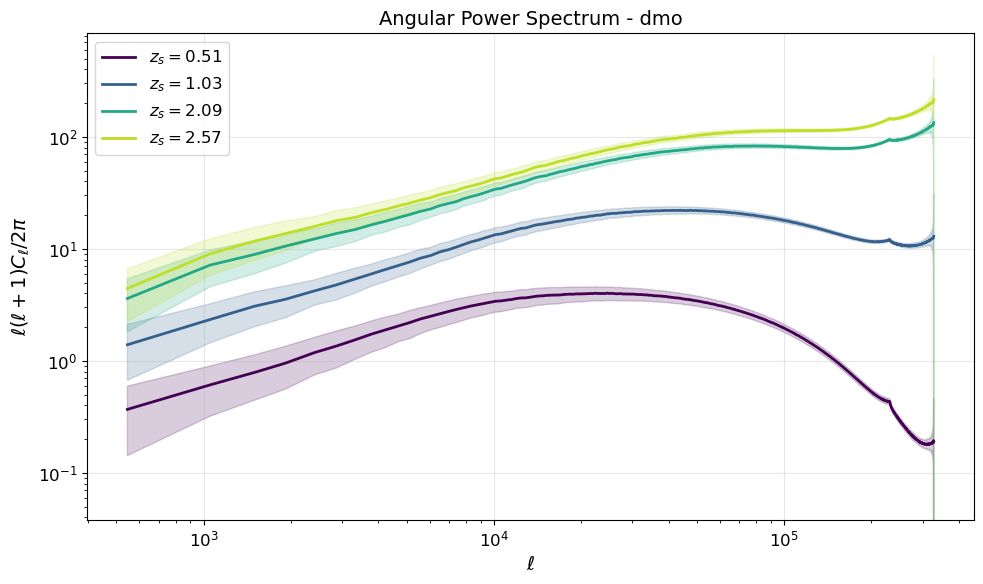

C_ℓ shape: (2000, 4, 724) (N_real, N_z, N_ell)


In [20]:
# Plot C_ell
if 'Cl' in data and 'ell_bins' in data:
    Cl = data['Cl']  # Shape: (N_real, N_z, N_ell)
    ell = data['ell_bins']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        Cl_mean = np.nanmean(Cl[:, z_idx, :], axis=0)
        Cl_std = np.nanstd(Cl[:, z_idx, :], axis=0)
        
        ax.loglog(ell, ell * (ell + 1) * Cl_mean / (2 * np.pi), 
                  color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(ell, 
                        ell * (ell + 1) * (Cl_mean - Cl_std) / (2 * np.pi),
                        ell * (ell + 1) * (Cl_mean + Cl_std) / (2 * np.pi),
                        color=color, alpha=0.2)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$')
    ax.set_title(f'Angular Power Spectrum - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"C_ℓ shape: {Cl.shape} (N_real, N_z, N_ell)")
else:
    print("C_ℓ data not available")

---
## 3. Peak Counts

Peak counts measure the number density of local maxima (peaks) in the smoothed convergence field as a function of signal-to-noise ratio $\nu$:

$$n_\text{peak}(\nu) = \frac{dN_\text{peak}}{d\nu}$$

where the signal-to-noise is defined as:

$$\nu = \frac{\kappa}{\sigma_0}$$

and $\sigma_0$ is the RMS of the DMO field (used as normalization). Peaks are detected as pixels where:

$$\kappa(x, y) > \kappa(x', y') \quad \forall \, |x'-x| \leq 1, |y'-y| \leq 1$$

High-$\nu$ peaks correspond to massive halos; low/negative $\nu$ peaks trace voids and noise.

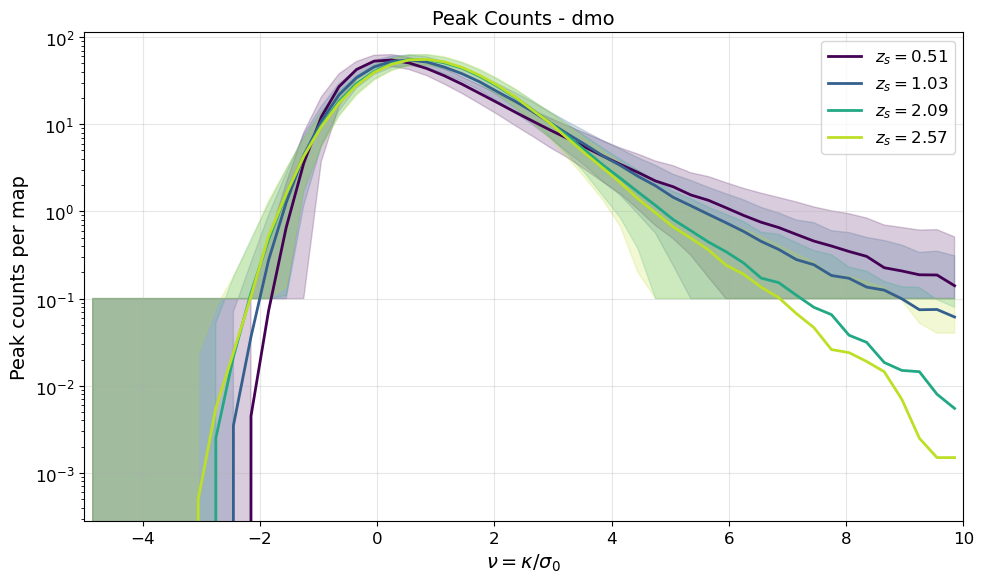

Peak counts shape: (2000, 4, 50) (N_real, N_z, N_bins)


In [21]:
# Plot Peak Counts
if 'peaks' in data and 'sn_bin_edges' in data:
    peaks = data['peaks']  # Shape: (N_real, N_z, N_bins)
    sn_edges = data['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        peaks_mean = np.nanmean(peaks[:, z_idx, :], axis=0)
        peaks_std = np.nanstd(peaks[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, peaks_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers, 
                        np.maximum(peaks_mean - peaks_std, 0.1),
                        peaks_mean + peaks_std,
                        color=color, alpha=0.2)
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Peak counts per map')
    ax.set_title(f'Peak Counts - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 10)
    plt.tight_layout()
    plt.show()
    
    print(f"Peak counts shape: {peaks.shape} (N_real, N_z, N_bins)")
else:
    print("Peak counts data not available")

---
## 4. Minima Counts

Minima counts are analogous to peak counts but measure local minima (troughs):

$$n_\text{min}(\nu) = \frac{dN_\text{min}}{d\nu}$$

Minima are detected as pixels where:

$$\kappa(x, y) < \kappa(x', y') \quad \forall \, |x'-x| \leq 1, |y'-y| \leq 1$$

Minima at negative $\nu$ correspond to underdense regions (voids), which are also affected by baryonic physics through processes like AGN feedback that can push gas out of halos.

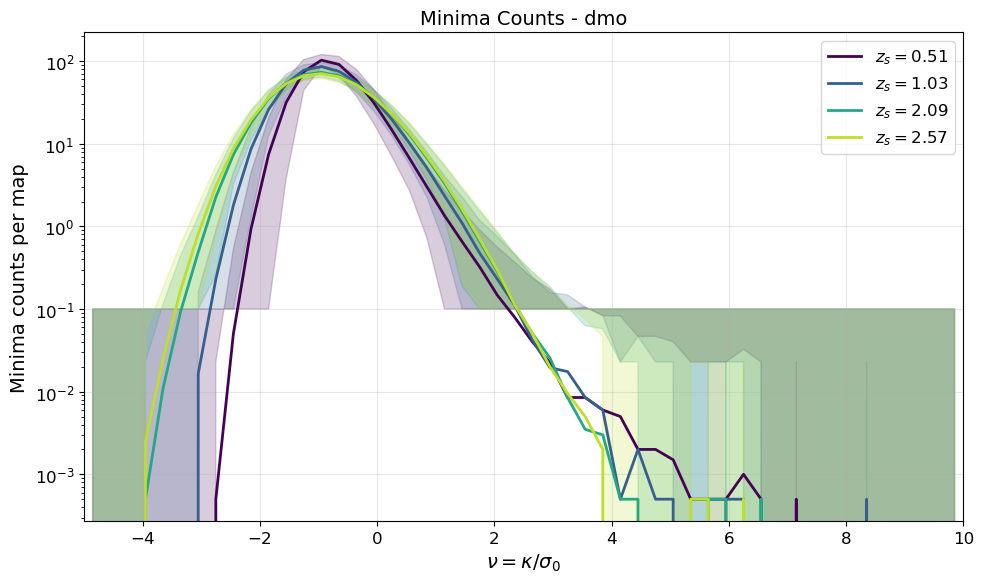

Minima counts shape: (2000, 4, 50) (N_real, N_z, N_bins)


In [22]:
# Plot Minima Counts
if 'minima' in data and 'sn_bin_edges' in data:
    minima = data['minima']  # Shape: (N_real, N_z, N_bins)
    sn_edges = data['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        minima_mean = np.nanmean(minima[:, z_idx, :], axis=0)
        minima_std = np.nanstd(minima[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, minima_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers,
                        np.maximum(minima_mean - minima_std, 0.1),
                        minima_mean + minima_std,
                        color=color, alpha=0.2)
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Minima counts per map')
    ax.set_title(f'Minima Counts - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 10)
    plt.tight_layout()
    plt.show()
    
    print(f"Minima counts shape: {minima.shape} (N_real, N_z, N_bins)")
else:
    print("Minima counts data not available")

---
## 5. Pixel PDF (Probability Distribution Function)

The one-point PDF measures the probability distribution of convergence values:

$$P(\kappa) = \frac{1}{N_\text{pix}} \frac{dN}{d\kappa}$$

For a Gaussian random field, this would be:

$$P(\nu) = \frac{1}{\sqrt{2\pi}} e^{-\nu^2/2}$$

Deviations from Gaussianity (skewness, kurtosis) encode information about non-linear structure formation and baryonic effects.

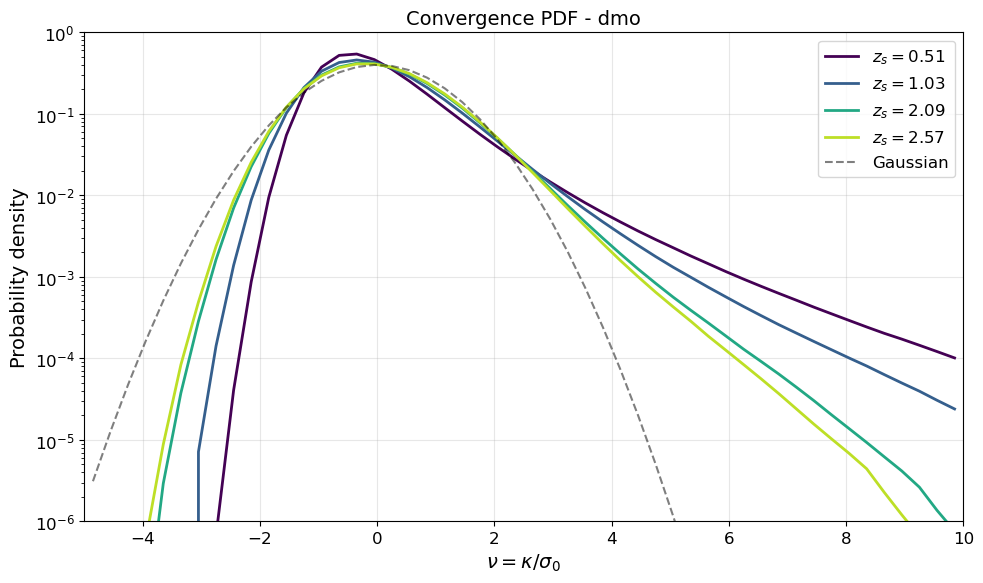

PDF shape: (2000, 4, 50) (N_real, N_z, N_bins)


In [23]:
# Plot PDF
if 'pdf' in data and 'sn_bin_edges' in data:
    pdf = data['pdf']  # Shape: (N_real, N_z, N_bins)
    sn_edges = data['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    bin_width = sn_edges[1] - sn_edges[0]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Normalize to get probability density
        pdf_mean = np.nanmean(pdf[:, z_idx, :], axis=0)
        pdf_norm = pdf_mean / (np.sum(pdf_mean) * bin_width)
        
        ax.semilogy(sn_centers, pdf_norm, color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    # Add Gaussian reference
    gaussian = np.exp(-sn_centers**2 / 2) / np.sqrt(2 * np.pi)
    ax.semilogy(sn_centers, gaussian, 'k--', lw=1.5, alpha=0.5, label='Gaussian')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Probability density')
    ax.set_title(f'Convergence PDF - {MODEL}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 10)
    ax.set_ylim(1e-6, 1)
    plt.tight_layout()
    plt.show()
    
    print(f"PDF shape: {pdf.shape} (N_real, N_z, N_bins)")
else:
    print("PDF data not available")

---
## 6. Minkowski Functionals

Minkowski functionals (MFs) characterize the morphology of excursion sets $\mathcal{E}_\nu = \{x : \kappa(x) \geq \nu\sigma_0\}$. In 2D, there are three MFs:

**$V_0$ (Area Fraction):** Fraction of pixels above threshold
$$V_0(\nu) = \frac{1}{A} \int_{\mathcal{E}_\nu} d^2x$$

**$V_1$ (Perimeter):** Boundary length of excursion set, normalized
$$V_1(\nu) = \frac{1}{4A} \oint_{\partial\mathcal{E}_\nu} dl$$

**$V_2$ (Euler Characteristic):** Topology measure = #connected regions - #holes
$$V_2(\nu) = \frac{1}{2\pi A} \oint_{\partial\mathcal{E}_\nu} \kappa_g \, dl$$

where $\kappa_g$ is the geodesic curvature of the boundary. For a Gaussian field, MFs have analytic predictions.

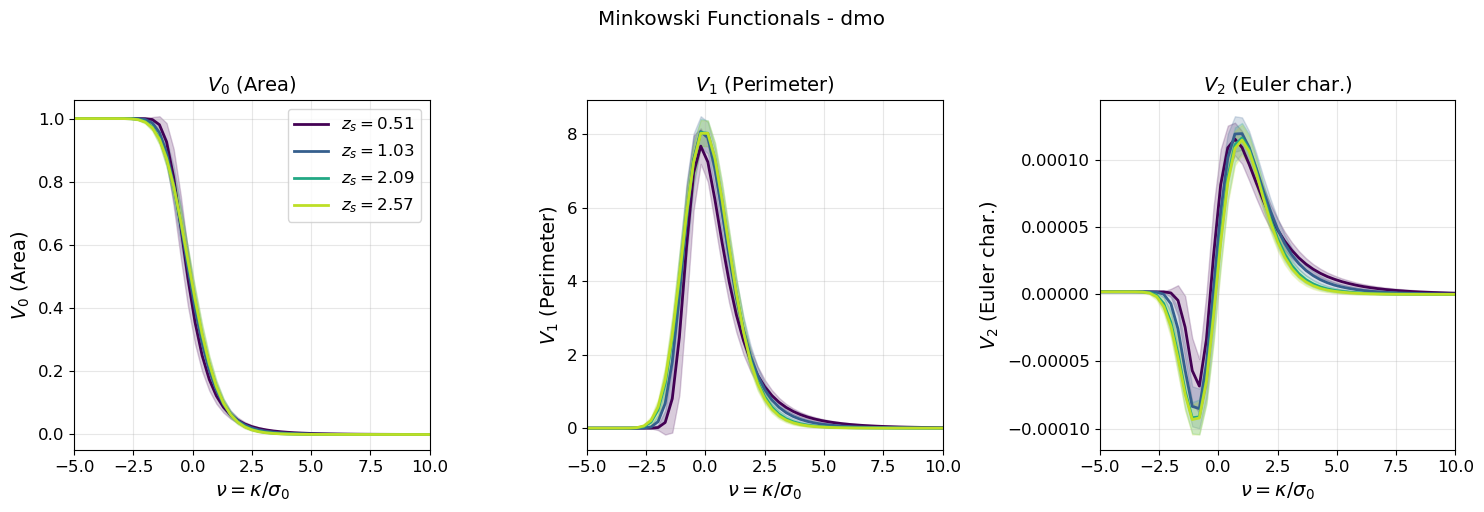

Minkowski functionals shape: (2000, 4, 51) (N_real, N_z, N_thresh)


In [24]:
# Plot Minkowski Functionals
if all(k in data for k in ['V0', 'V1', 'V2', 'mf_thresholds']):
    V0 = data['V0']  # Shape: (N_real, N_z, N_thresh)
    V1 = data['V1']
    V2 = data['V2']
    nu = data['mf_thresholds']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    MFs = [V0, V1, V2]
    titles = [r'$V_0$ (Area)', r'$V_1$ (Perimeter)', r'$V_2$ (Euler char.)']
    
    for ax, MF, title in zip(axes, MFs, titles):
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            MF_mean = np.nanmean(MF[:, z_idx, :], axis=0)
            MF_std = np.nanstd(MF[:, z_idx, :], axis=0)
            
            ax.plot(nu, MF_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
            ax.fill_between(nu, MF_mean - MF_std, MF_mean + MF_std, color=color, alpha=0.2)
        
        ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 10)
    
    axes[0].legend(loc='upper right')
    fig.suptitle(f'Minkowski Functionals - {MODEL}', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"Minkowski functionals shape: {V0.shape} (N_real, N_z, N_thresh)")
else:
    print("Minkowski functionals data not available")

---
## 7. Wavelet Scattering Transform (WST)

The WST provides multi-scale, non-Gaussian statistics by iteratively applying wavelet transforms and taking moduli. For a field $\kappa$:

**$S_0$ (Zeroth order):** Moments of the absolute field
$$S_0(p) = \langle |\kappa|^p \rangle$$

**$S_1$ (First order):** Moments of wavelet-filtered field at scale $j$
$$S_1(j, p) = \langle |\kappa \ast \psi_j|^p \rangle$$

where $\psi_j$ are wavelets at scale $2^j$, and $p \in \{0.5, 1, 2\}$ are moment orders.

The wavelets are bump-steerable wavelets (Lanusse+2012) with cutoff frequencies $k_c \cdot 2^{-j}$. WST coefficients capture non-Gaussian information beyond the power spectrum.

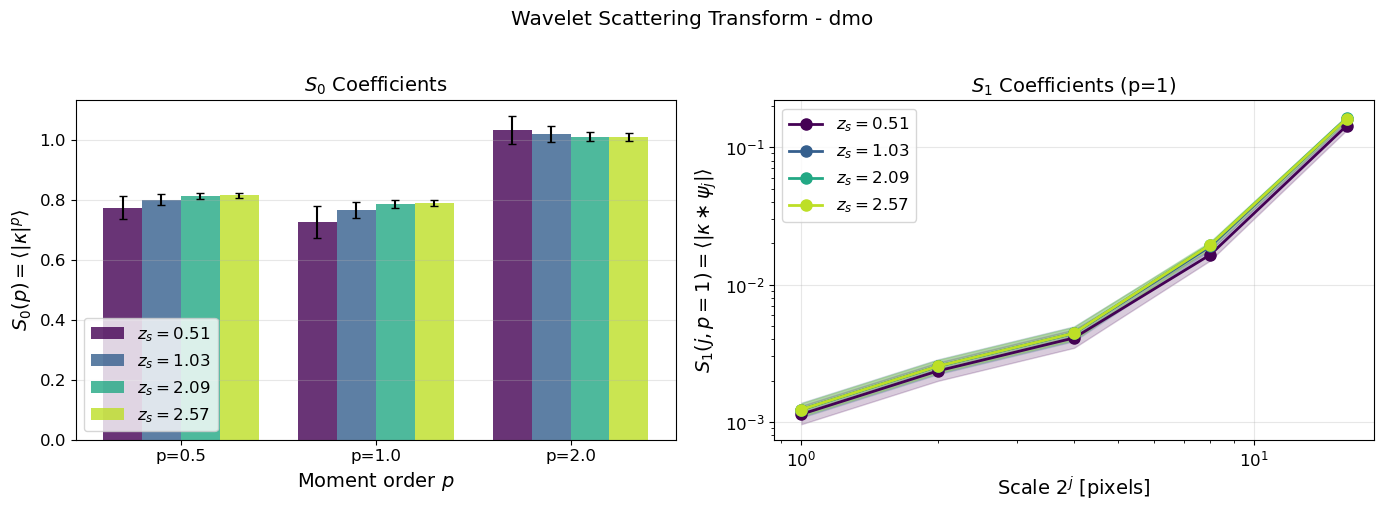

S0 shape: (2000, 4, 3), S1 shape: (2000, 4, 5, 3)
Scales: [ 1.  2.  4.  8. 16.], Moments: [0.5 1.  2. ]


In [25]:
# Plot Wavelet Scattering Transform
if all(k in data for k in ['S0', 'S1', 'wst_scales', 'wst_moments']):
    S0 = data['S0']  # Shape: (N_real, N_z, N_moments)
    S1 = data['S1']  # Shape: (N_real, N_z, N_scales, N_moments)
    scales = data['wst_scales']
    moments = data['wst_moments']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    moment_labels = [f'p={p}' for p in moments]
    
    # S0 plot (bar chart)
    ax = axes[0]
    x = np.arange(len(moments))
    width = 0.2
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        S0_mean = np.nanmean(S0[:, z_idx, :], axis=0)
        S0_std = np.nanstd(S0[:, z_idx, :], axis=0)
        ax.bar(x + z_idx * width, S0_mean, width, color=color, label=f'$z_s = {z:.2f}$',
               yerr=S0_std, capsize=3, alpha=0.8)
    
    ax.set_xlabel('Moment order $p$')
    ax.set_ylabel(r'$S_0(p) = \langle |\kappa|^p \rangle$')
    ax.set_title(r'$S_0$ Coefficients')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(moment_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # S1 plot (vs scale, for p=1)
    ax = axes[1]
    p_idx = 1  # p=1.0
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        S1_mean = np.nanmean(S1[:, z_idx, :, p_idx], axis=0)
        S1_std = np.nanstd(S1[:, z_idx, :, p_idx], axis=0)
        ax.loglog(scales, S1_mean, 'o-', color=color, lw=2, ms=8, label=f'$z_s = {z:.2f}$')
        ax.fill_between(scales, S1_mean - S1_std, S1_mean + S1_std, color=color, alpha=0.2)
    
    ax.set_xlabel('Scale $2^j$ [pixels]')
    ax.set_ylabel(r'$S_1(j, p=1) = \langle |\kappa \ast \psi_j| \rangle$')
    ax.set_title(r'$S_1$ Coefficients (p=1)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'Wavelet Scattering Transform - {MODEL}', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"S0 shape: {S0.shape}, S1 shape: {S1.shape}")
    print(f"Scales: {scales}, Moments: {moments}")
else:
    print("WST data not available")

---
## 8. Bispectrum

The bispectrum measures three-point correlations in Fourier space, quantifying non-Gaussianity:

$$B(\ell_1, \ell_2, \ell_3) = \langle \tilde{\kappa}(\boldsymbol{\ell}_1) \tilde{\kappa}(\boldsymbol{\ell}_2) \tilde{\kappa}(\boldsymbol{\ell}_3) \rangle$$

with $\boldsymbol{\ell}_1 + \boldsymbol{\ell}_2 + \boldsymbol{\ell}_3 = 0$ (triangle closure). We compute four configurations:

| Configuration | Triangle Shape | Estimator |
|--------------|----------------|-----------|
| **Equilateral** | $\ell_1 \approx \ell_2 \approx \ell_3$ | $\langle \kappa(\ell)^3 \rangle$ |
| **Squeezed** | $\ell_1 \ll \ell_2 \approx \ell_3$ | $\langle \kappa_\text{low} \cdot |\kappa(\ell)|^2 \rangle$ |
| **Folded** | $\ell_1 \approx 2\ell_2 \approx 2\ell_3$ | $\langle \kappa(\ell) \cdot \kappa(\ell/2)^2 \rangle$ |
| **Isosceles** | $\ell_1 = \ell_2 \neq \ell_3$ | $\langle |\kappa(\ell)|^2 \cdot \kappa(\ell') \rangle$ |

Different configurations are sensitive to different physical processes and halo masses.

/tmp/ipykernel_2362642/62524414.py:25: RuntimeWarning: Mean of empty slice
  bispec_mean = np.nanmean(bispec[:, z_idx, :], axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


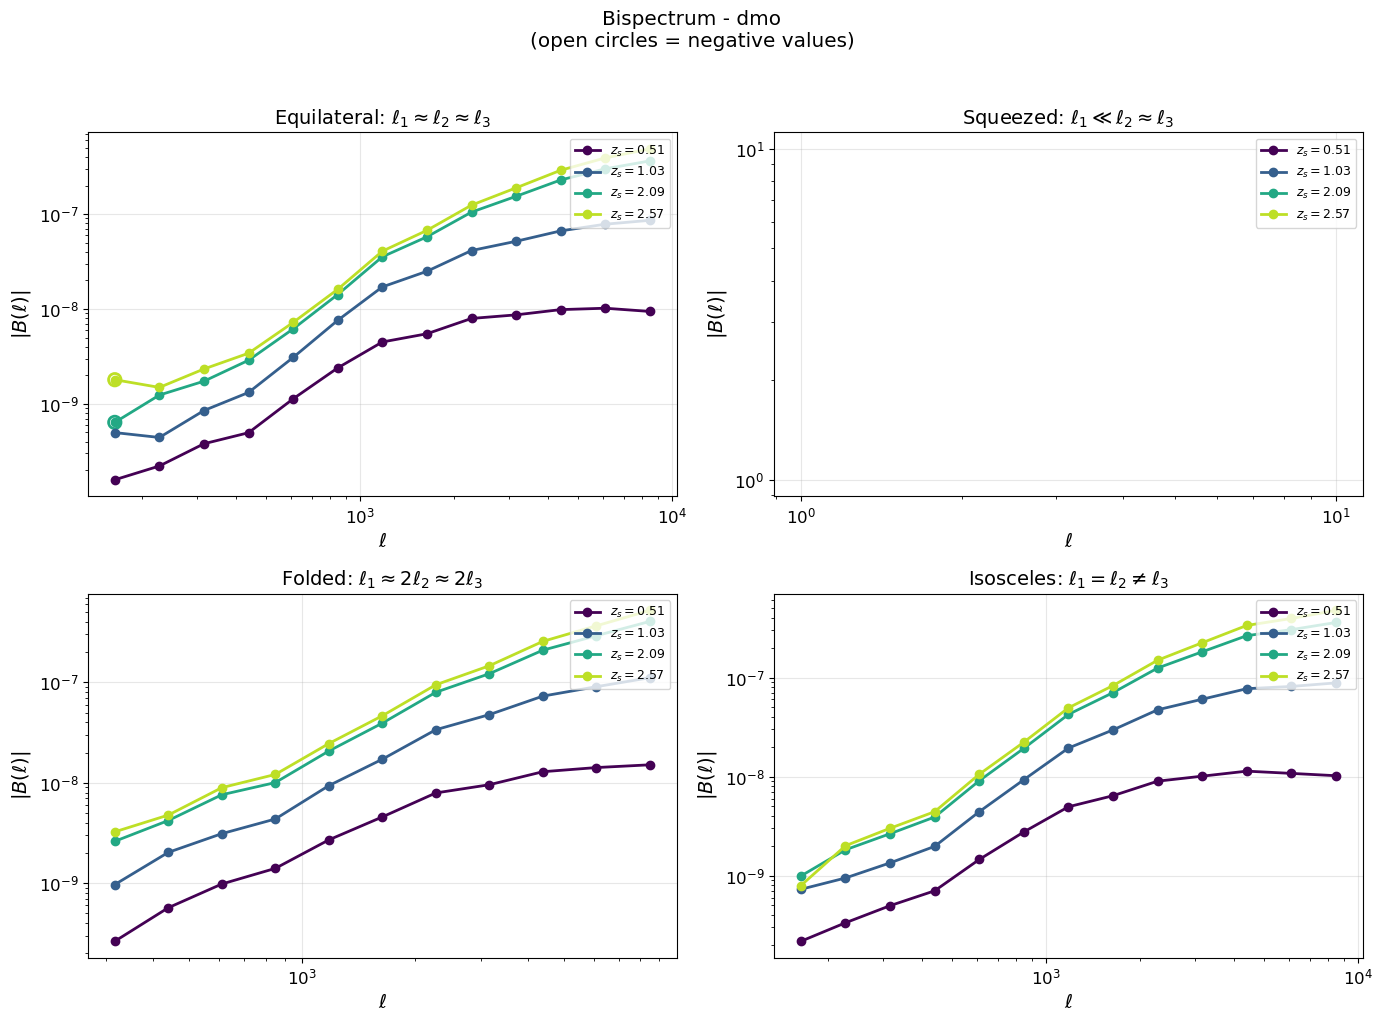

Bispectrum ell bins: 14
Bispectrum shape: (2000, 4, 14) (N_real, N_z, N_ell)


In [26]:
# Plot Bispectrum
bispec_keys = ['bispec_equilateral', 'bispec_squeezed', 'bispec_folded', 'bispec_isosceles']
if 'bispec_ell' in data and any(k in data for k in bispec_keys):
    ell_bispec = data['bispec_ell']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    configs = ['equilateral', 'squeezed', 'folded', 'isosceles']
    config_titles = [
        r'Equilateral: $\ell_1 \approx \ell_2 \approx \ell_3$',
        r'Squeezed: $\ell_1 \ll \ell_2 \approx \ell_3$',
        r'Folded: $\ell_1 \approx 2\ell_2 \approx 2\ell_3$',
        r'Isosceles: $\ell_1 = \ell_2 \neq \ell_3$'
    ]
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for ax, config, title in zip(axes, configs, config_titles):
        key = f'bispec_{config}'
        if key in data:
            bispec = data[key]  # Shape: (N_real, N_z, N_ell)
            
            for z_idx, (z, color) in enumerate(zip(source_z, colors)):
                bispec_mean = np.nanmean(bispec[:, z_idx, :], axis=0)
                bispec_std = np.nanstd(bispec[:, z_idx, :], axis=0)
                
                # Handle negative values with abs and sign
                sign = np.sign(bispec_mean)
                abs_bispec = np.abs(bispec_mean)
                
                ax.loglog(ell_bispec, abs_bispec, 'o-', color=color, lw=2, ms=6, 
                         label=f'$z_s = {z:.2f}$')
                
                # Mark negative values with open circles
                neg_mask = sign < 0
                if np.any(neg_mask):
                    ax.scatter(ell_bispec[neg_mask], abs_bispec[neg_mask], 
                              facecolors='none', edgecolors=color, s=80, linewidths=2)
            
            ax.set_xlabel(r'$\ell$')
            ax.set_ylabel(r'$|B(\ell)|$')
            ax.set_title(title)
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', 
                   transform=ax.transAxes)
            ax.set_title(title)
    
    fig.suptitle(f'Bispectrum - {MODEL}\n(open circles = negative values)', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"Bispectrum ell bins: {len(ell_bispec)}")
    if bispec_keys[0] in data:
        print(f"Bispectrum shape: {data[bispec_keys[0]].shape} (N_real, N_z, N_ell)")
else:
    print("Bispectrum data not available")

---
## Summary Statistics Table

Quick overview of all statistics computed:

In [27]:
# Summary table
print(f"Statistics Summary for: {MODEL}")
print("=" * 70)
print(f"{'Statistic':<25} {'Shape':<30} {'Description'}")
print("-" * 70)

stat_info = [
    ('Pk', 'Power spectrum P(k)'),
    ('k_bins', 'Wavenumber bins'),
    ('Cl', 'Angular power spectrum C_ℓ'),
    ('ell_bins', 'Multipole bins'),
    ('peaks', 'Peak counts'),
    ('minima', 'Minima counts'),
    ('pdf', 'Pixel PDF'),
    ('sn_bin_edges', 'S/N bin edges'),
    ('V0', 'Minkowski V0 (area)'),
    ('V1', 'Minkowski V1 (perimeter)'),
    ('V2', 'Minkowski V2 (Euler)'),
    ('mf_thresholds', 'MF threshold values'),
    ('S0', 'WST zeroth order'),
    ('S1', 'WST first order'),
    ('wst_scales', 'WST scale factors'),
    ('wst_moments', 'WST moment orders'),
    ('bispec_ell', 'Bispectrum ℓ bins'),
    ('bispec_equilateral', 'Bispectrum (equilateral)'),
    ('bispec_squeezed', 'Bispectrum (squeezed)'),
    ('bispec_folded', 'Bispectrum (folded)'),
    ('bispec_isosceles', 'Bispectrum (isosceles)'),
]

for key, desc in stat_info:
    if key in data:
        shape_str = str(data[key].shape)
        print(f"{key:<25} {shape_str:<30} {desc}")
    else:
        print(f"{key:<25} {'N/A':<30} {desc}")

print("-" * 70)
print(f"\nTotal realizations: {attrs.get('N_LP', 'N/A')} LPs × {attrs.get('N_RUNS', 'N/A')} runs")
print(f"Source redshifts: {list(source_z)}")

Statistics Summary for: dmo
Statistic                 Shape                          Description
----------------------------------------------------------------------
Pk                        (20, 40, 2896)                 Power spectrum P(k)
k_bins                    (2896,)                        Wavenumber bins
Cl                        (2000, 4, 724)                 Angular power spectrum C_ℓ
ell_bins                  (724,)                         Multipole bins
peaks                     (2000, 4, 50)                  Peak counts
minima                    (2000, 4, 50)                  Minima counts
pdf                       (2000, 4, 50)                  Pixel PDF
sn_bin_edges              (51,)                          S/N bin edges
V0                        (2000, 4, 51)                  Minkowski V0 (area)
V1                        (2000, 4, 51)                  Minkowski V1 (perimeter)
V2                        (2000, 4, 51)                  Minkowski V2 (Euler)
mf_threshol

---
# Hydro vs DMO Comparison

This section compares the hydrodynamical simulation (with full baryonic physics) to the dark matter only (DMO) simulation. The ratio $S_\text{Hydro}/S_\text{DMO}$ quantifies the **baryonic suppression/enhancement** for each statistic.

Key baryonic effects:
- **AGN feedback**: Expels gas from halos, reducing small-scale power
- **Cooling & star formation**: Concentrates baryons, can enhance central densities
- **Net effect**: Typically suppression at $k \gtrsim 1 \, h/\text{Mpc}$ or $\ell \gtrsim 1000$

In [61]:
# Load both DMO and Hydro statistics
def load_model_stats(model_name):
    """Load all statistics for a model."""
    stats_path = STATS_BASE / model_name / 'stats.h5'
    if not stats_path.exists():
        print(f"WARNING: {stats_path} not found")
        return None, None
    
    with h5py.File(stats_path, 'r') as f:
        data = {}
        for key in f.keys():
            if isinstance(f[key], h5py.Dataset):
                data[key] = f[key][:]
        attrs = dict(f.attrs)
    return data, attrs

# Load both models
print("Loading DMO and Hydro statistics...")
data_dmo, attrs_dmo = load_model_stats('dmo')
data_hydro, attrs_hydro = load_model_stats('hydro')

if data_dmo is not None:
    print(f"DMO: {len(data_dmo)} datasets loaded")
if data_hydro is not None:
    print(f"Hydro: {len(data_hydro)} datasets loaded")

# Use DMO source redshifts
source_z = attrs_dmo.get('source_redshifts', [0.5, 1.0, 2.0, 2.5]) if attrs_dmo else [0.5, 1.0, 2.0, 2.5]

Loading DMO and Hydro statistics...


DMO: 12 datasets loaded
Hydro: 12 datasets loaded


## Power Spectrum Ratio $P_\text{Hydro}(k) / P_\text{DMO}(k)$

The matter power spectrum suppression due to baryons is the classic test of baryonic effects. We expect:
- Unity at large scales ($k \lesssim 0.1 \, h/\text{Mpc}$)
- Suppression of 10-30% at $k \sim 1-10 \, h/\text{Mpc}$ (AGN feedback)
- Possible enhancement at very small scales (star formation)

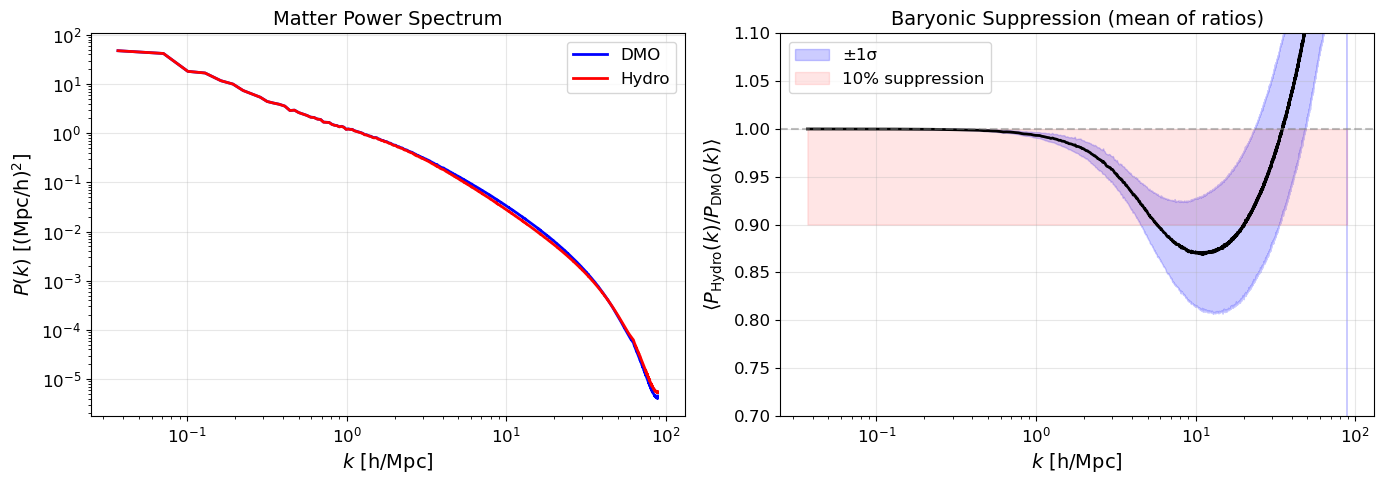

P(k) data not available for both models


In [62]:
# P(k) ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'Pk' in data_dmo and 'Pk' in data_hydro:
    Pk_dmo = data_dmo['Pk']
    Pk_hydro = data_hydro['Pk']
    k = data_dmo['k_bins']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Absolute P(k)
    ax = axes[0]
    Pk_dmo_mean = np.nanmean(Pk_dmo, axis=(0, 1))
    Pk_hydro_mean = np.nanmean(Pk_hydro, axis=(0, 1))
    
    ax.loglog(k, Pk_dmo_mean, 'b-', lw=2, label='DMO')
    ax.loglog(k, Pk_hydro_mean, 'r-', lw=2, label='Hydro')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P(k)$ [(Mpc/h)$^2$]')
    ax.set_title('Matter Power Spectrum')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: Ratio - compute per-realization ratio then average
    ax = axes[1]
    # Compute ratio per LP/plane, then average (cancels cosmic variance)
    ratio_per_real = Pk_hydro / Pk_dmo  # Shape: (N_LP, N_planes, N_k)
    ratio_mean = np.nanmean(ratio_per_real, axis=(0, 1))
    ratio_std = np.nanstd(ratio_per_real, axis=(0, 1))
    
    ax.semilogx(k, ratio_mean, 'k-', lw=2)
    ax.fill_between(k, ratio_mean - ratio_std, ratio_mean + ratio_std, alpha=0.2, color='blue', label='±1σ')
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(k, 0.9, 1.0, alpha=0.1, color='red', label='10% suppression')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$\langle P_\text{Hydro}(k) / P_\text{DMO}(k) \rangle$')
    ax.set_title('Baryonic Suppression (mean of ratios)')
    ax.set_ylim(0.7, 1.1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print max suppression

    min_ratio = np.nanmin(ratio_mean)    
    print("P(k) data not available for both models")

    k_min = k[np.nanargmin(ratio_mean)]
else:
    print(f"Maximum suppression: {(1-min_ratio)*100:.1f}% at k = {k_min:.2f} h/Mpc")

## Angular Power Spectrum Ratio $C_\ell^\text{Hydro} / C_\ell^\text{DMO}$

The convergence power spectrum integrates the matter power spectrum along the line of sight. The baryonic suppression:
- Appears at $\ell \gtrsim 1000$ (corresponding to $k \gtrsim 1 \, h/\text{Mpc}$)
- Depends on source redshift due to different weight functions

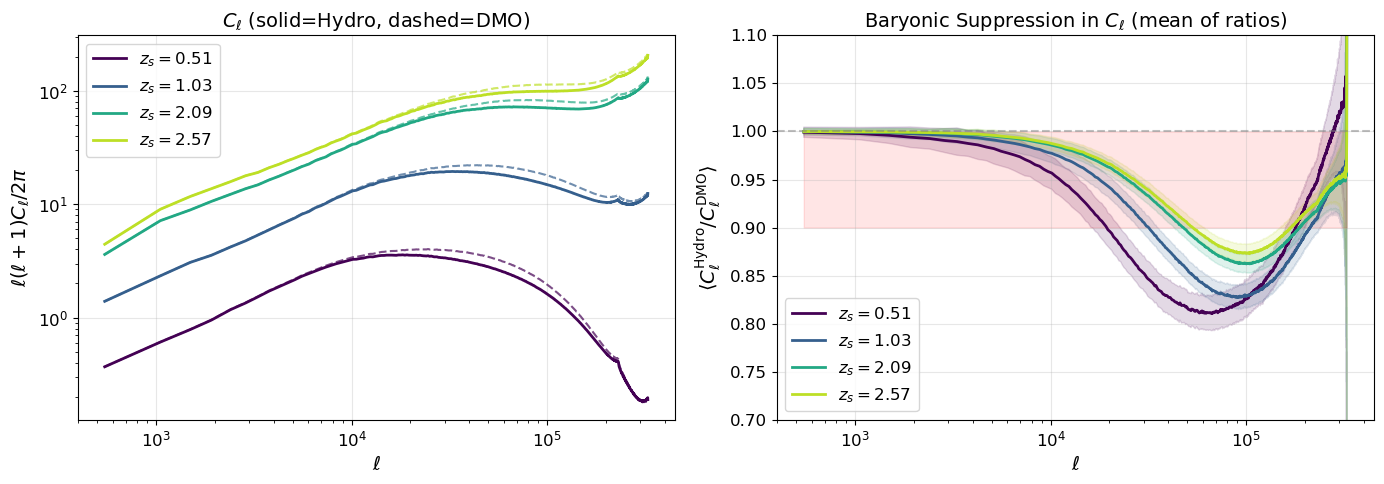

In [63]:
# C_ell ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'Cl' in data_dmo and 'Cl' in data_hydro:
    Cl_dmo = data_dmo['Cl']
    Cl_hydro = data_hydro['Cl']
    ell = data_dmo['ell_bins']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute C_ell
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        Cl_dmo_mean = np.nanmean(Cl_dmo[:, z_idx, :], axis=0)
        Cl_hydro_mean = np.nanmean(Cl_hydro[:, z_idx, :], axis=0)
        
        ax.loglog(ell, ell * (ell + 1) * Cl_dmo_mean / (2 * np.pi), 
                  '--', color=color, lw=1.5, alpha=0.7)
        ax.loglog(ell, ell * (ell + 1) * Cl_hydro_mean / (2 * np.pi), 
                  '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$')
    ax.set_title(r'$C_\ell$ (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: Ratio - compute per-realization ratio then average
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Compute ratio per realization, then average (cancels cosmic variance)
        ratio_per_real = Cl_hydro[:, z_idx, :] / Cl_dmo[:, z_idx, :]  # Shape: (N_real, N_ell)
        ratio_mean = np.nanmean(ratio_per_real, axis=0)
        ratio_std = np.nanstd(ratio_per_real, axis=0)
        
        ax.semilogx(ell, ratio_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(ell, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(ell, 0.9, 1.0, alpha=0.1, color='red')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\langle C_\ell^\text{Hydro} / C_\ell^\text{DMO} \rangle$')
    ax.set_title('Baryonic Suppression in $C_\ell$ (mean of ratios)')
    ax.set_ylim(0.7, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:    print("C_ℓ data not available for both models")

## Peak Counts Ratio

Peak counts are sensitive to baryonic effects because:
- High-$\nu$ peaks trace massive halos where AGN feedback is strongest
- Baryons modify the halo mass-concentration relation
- The response is **ν-dependent**: different at low vs high S/N

/tmp/ipykernel_2362642/3266292962.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = N_H / N_D
/tmp/ipykernel_2362642/3266292962.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
/tmp/ipykernel_2362642/3266292962.py:38: RuntimeWarning: invalid value encountered in multiply
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)


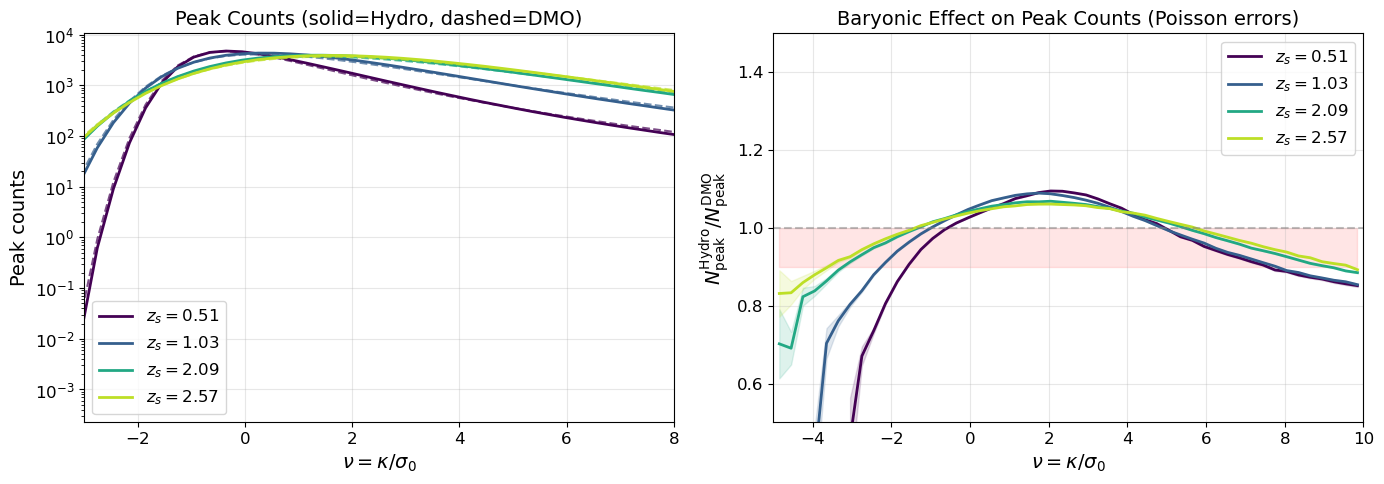

In [65]:
# Peak counts ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'peaks' in data_dmo and 'peaks' in data_hydro:
    peaks_dmo = data_dmo['peaks']
    peaks_hydro = data_hydro['peaks']
    sn_edges = data_dmo['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute counts
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        peaks_dmo_mean = np.nanmean(peaks_dmo[:, z_idx, :], axis=0)
        peaks_hydro_mean = np.nanmean(peaks_hydro[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, peaks_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, peaks_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Peak counts')
    ax.set_title('Peak Counts (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3, 8)
    
    # Right: Ratio with Poisson errors from total counts
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Sum over all realizations for total counts
        N_H = np.nansum(peaks_hydro[:, z_idx, :], axis=0)  # Total Hydro counts per bin
        N_D = np.nansum(peaks_dmo[:, z_idx, :], axis=0)    # Total DMO counts per bin
        
        # Ratio of total counts
        ratio = N_H / N_D
        
        # Poisson error on ratio: σ_R/R = sqrt(1/N_H + 1/N_D)
        ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
        
        # Mask where counts are too low
        mask = (N_D > 10) & (N_H > 10)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(sn_centers, 0.9, 1.0, alpha=0.1, color='red')
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N_\text{peak}^\text{Hydro} / N_\text{peak}^\text{DMO}$')
    ax.set_title('Baryonic Effect on Peak Counts (Poisson errors)')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.5, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()


    plt.show()    

else:       print("Peak counts data not available for both models")

## Minima Counts Ratio

Minima (voids) are also affected by baryons:
- AGN feedback pushes gas into voids, potentially making them less underdense
- The effect is generally smaller than for peaks

/tmp/ipykernel_2362642/761289103.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = N_H / N_D
/tmp/ipykernel_2362642/761289103.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)


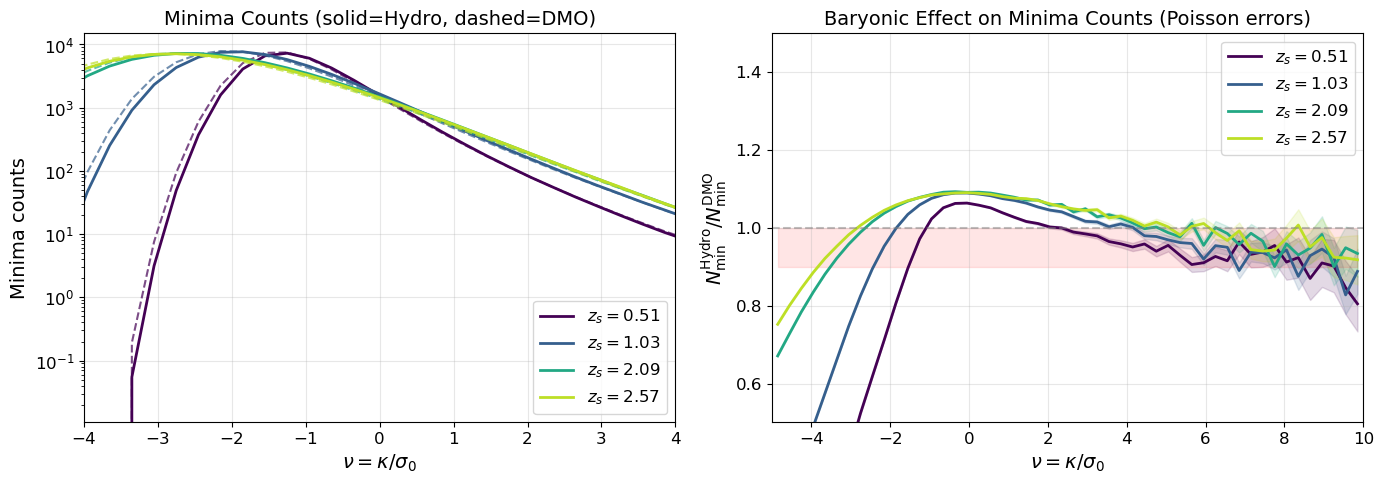

In [68]:
# Minima counts ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'minima' in data_dmo and 'minima' in data_hydro:
    minima_dmo = data_dmo['minima']
    minima_hydro = data_hydro['minima']
    sn_edges = data_dmo['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute counts
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        minima_dmo_mean = np.nanmean(minima_dmo[:, z_idx, :], axis=0)
        minima_hydro_mean = np.nanmean(minima_hydro[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, minima_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, minima_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('Minima counts')
    ax.set_title('Minima Counts (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 4)
    
    # Right: Ratio with Poisson errors from total counts
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Sum over all realizations for total counts
        N_H = np.nansum(minima_hydro[:, z_idx, :], axis=0)  # Total Hydro counts per bin
        N_D = np.nansum(minima_dmo[:, z_idx, :], axis=0)    # Total DMO counts per bin
        
        # Ratio of total counts
        ratio = N_H / N_D
        
        # Poisson error on ratio: σ_R/R = sqrt(1/N_H + 1/N_D)
        ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
        
        # Mask where counts are too low
        mask = (N_D > 10) & (N_H > 10)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.fill_between(sn_centers, 0.9, 1.0, alpha=0.1, color='red')
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N_\text{min}^\text{Hydro} / N_\text{min}^\text{DMO}$')
    ax.set_title('Baryonic Effect on Minima Counts (Poisson errors)')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.5, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    

    plt.tight_layout()    


    plt.show()
else:     print("Minima counts data not available for both models")


## PDF Ratio

The one-point PDF ratio shows how baryons modify the distribution of convergence values:
- Suppression at high $\nu$ (fewer high-density peaks)
- Possible enhancement near $\nu \sim 0$ (redistribution of matter)

/tmp/ipykernel_2362642/2373452532.py:35: RuntimeWarning: invalid value encountered in divide
  ratio = N_H / N_D
/tmp/ipykernel_2362642/2373452532.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)


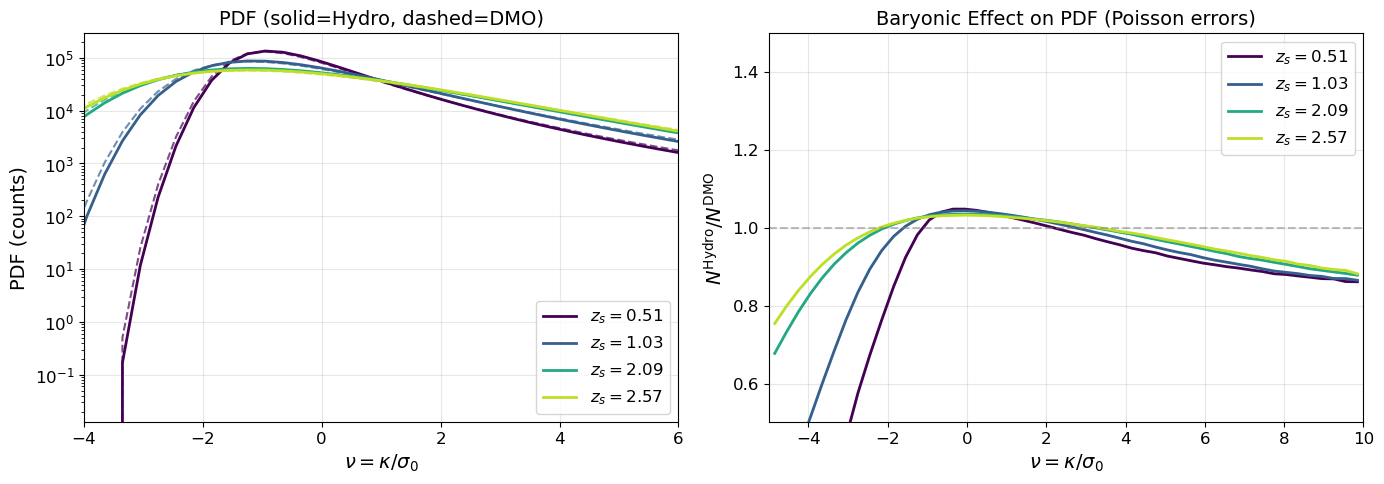

In [70]:
# PDF ratio: Hydro / DMO
if data_dmo is not None and data_hydro is not None and 'pdf' in data_dmo and 'pdf' in data_hydro:
    pdf_dmo = data_dmo['pdf']
    pdf_hydro = data_hydro['pdf']
    sn_edges = data_dmo['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: Absolute PDF
    ax = axes[0]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        pdf_dmo_mean = np.nanmean(pdf_dmo[:, z_idx, :], axis=0)
        pdf_hydro_mean = np.nanmean(pdf_hydro[:, z_idx, :], axis=0)
        
        ax.semilogy(sn_centers, pdf_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
        ax.semilogy(sn_centers, pdf_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
    
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel('PDF (counts)')
    ax.set_title('PDF (solid=Hydro, dashed=DMO)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 6)
    
    # Right: Ratio with Poisson errors from total counts
    ax = axes[1]
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Sum over all realizations for total counts
        N_H = np.nansum(pdf_hydro[:, z_idx, :], axis=0)  # Total Hydro counts per bin
        N_D = np.nansum(pdf_dmo[:, z_idx, :], axis=0)    # Total DMO counts per bin
        
        # Ratio of total counts
        ratio = N_H / N_D
        
        # Poisson error on ratio: σ_R/R = sqrt(1/N_H + 1/N_D)
        ratio_err = ratio * np.sqrt(1.0/N_H + 1.0/N_D)
        
        # Mask where counts are too low
        mask = (N_D > 100) & (N_H > 100)
        
        ax.plot(sn_centers[mask], ratio[mask], color=color, lw=2, label=f'$z_s = {z:.2f}$')
        ax.fill_between(sn_centers[mask], (ratio - ratio_err)[mask], (ratio + ratio_err)[mask], color=color, alpha=0.15)
    
    ax.axhline(1, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\nu = \kappa / \sigma_0$')
    ax.set_ylabel(r'$N^\text{Hydro} / N^\text{DMO}$')
    ax.set_title('Baryonic Effect on PDF (Poisson errors)')
    ax.set_xlim(-5, 10)
    ax.set_ylim(0.5, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("PDF data not available for both models")

## Minkowski Functionals Ratio

The three Minkowski functionals capture different morphological aspects:
- **$V_0$ (Area)**: Fraction of field above threshold
- **$V_1$ (Perimeter)**: Boundary complexity
- **$V_2$ (Euler)**: Topology (connected regions - holes)

/tmp/ipykernel_2362642/1811845748.py:46: RuntimeWarning: Mean of empty slice
  ratio_mean = np.nanmean(ratio_per_real, axis=0)


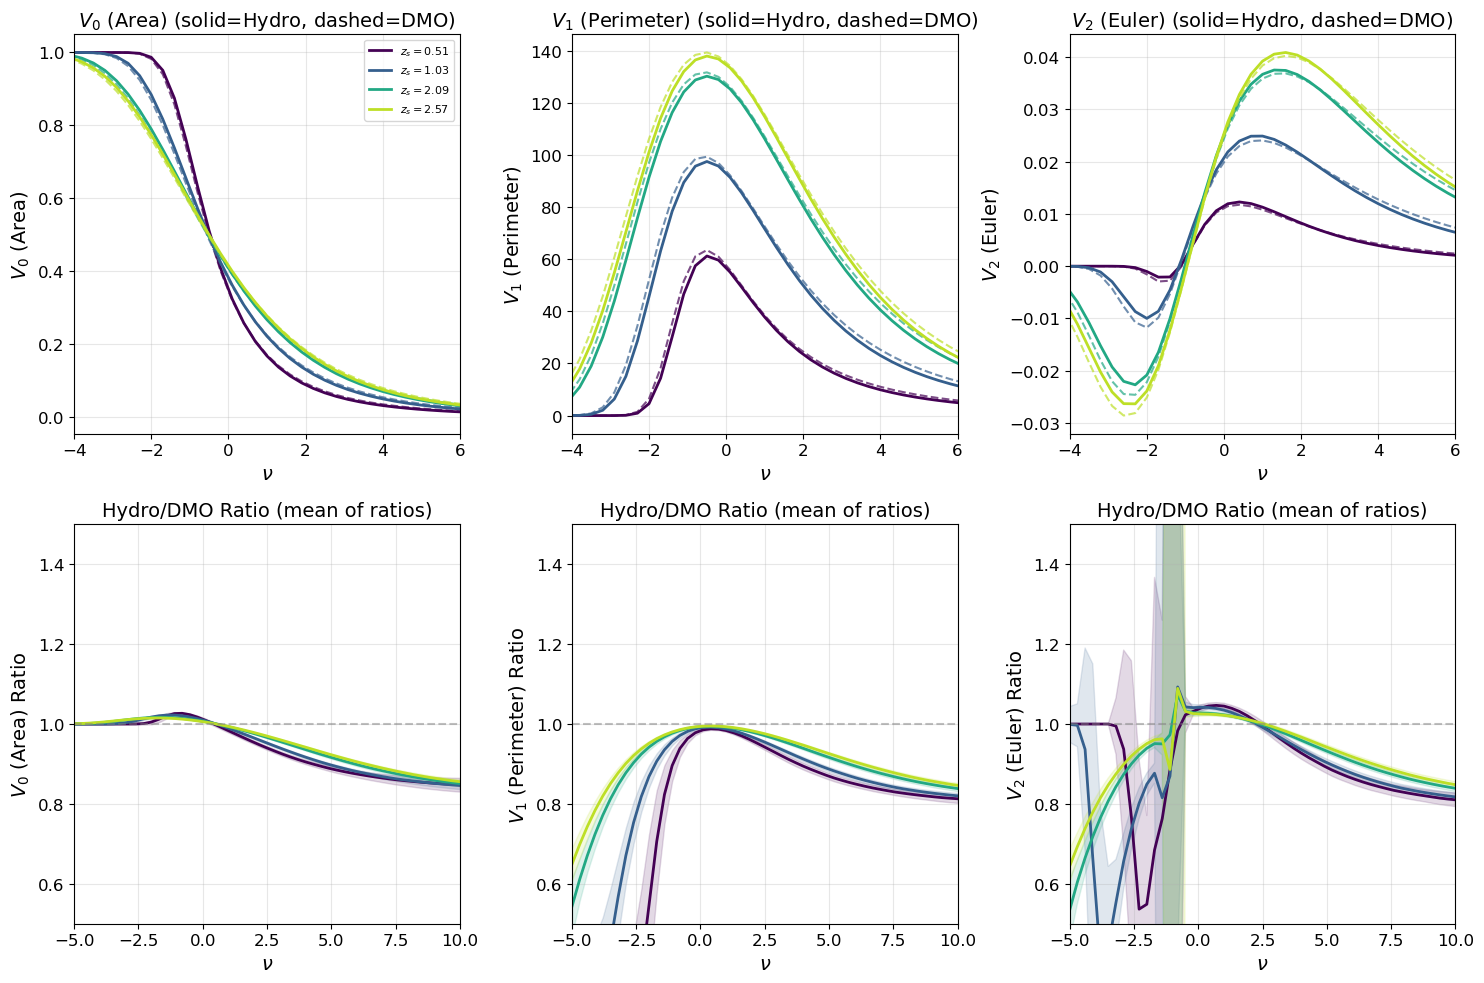

In [73]:
# Minkowski Functionals ratio: Hydro / DMO
mf_keys = ['V0', 'V1', 'V2']
if (data_dmo is not None and data_hydro is not None and 
    all(k in data_dmo for k in mf_keys) and all(k in data_hydro for k in mf_keys)):
    
    nu = data_dmo['mf_thresholds']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    mf_titles = [r'$V_0$ (Area)', r'$V_1$ (Perimeter)', r'$V_2$ (Euler)']
    
    # Top row: Absolute values
    for col, (key, title) in enumerate(zip(mf_keys, mf_titles)):
        ax = axes[0, col]
        MF_dmo = data_dmo[key]
        MF_hydro = data_hydro[key]
        
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            MF_dmo_mean = np.nanmean(MF_dmo[:, z_idx, :], axis=0)
            MF_hydro_mean = np.nanmean(MF_hydro[:, z_idx, :], axis=0)
            
            ax.plot(nu, MF_dmo_mean, '--', color=color, lw=1.5, alpha=0.7)
            ax.plot(nu, MF_hydro_mean, '-', color=color, lw=2, label=f'$z_s = {z:.2f}$')
        
        ax.set_xlabel(r'$\nu$')
        ax.set_ylabel(title)
        ax.set_title(f'{title} (solid=Hydro, dashed=DMO)')
        if col == 0:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-4, 6)
    
    # Bottom row: Ratios - compute per-realization ratio then average
    for col, (key, title) in enumerate(zip(mf_keys, mf_titles)):
        ax = axes[1, col]
        MF_dmo = data_dmo[key]
        MF_hydro = data_hydro[key]
        
        for z_idx, (z, color) in enumerate(zip(source_z, colors)):
            # Compute ratio per realization (cancels cosmic variance)
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio_per_real = MF_hydro[:, z_idx, :] / MF_dmo[:, z_idx, :]
                # Mask where DMO is too small (per realization)
                ratio_per_real = np.where(np.abs(MF_dmo[:, z_idx, :]) > 1e-6, ratio_per_real, np.nan)
            
            ratio_mean = np.nanmean(ratio_per_real, axis=0)
            ratio_std = np.nanstd(ratio_per_real, axis=0)
            
            ax.plot(nu, ratio_mean, color=color, lw=2, label=f'$z_s = {z:.2f}$')
            ax.fill_between(nu, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
        
        ax.axhline(1, color='gray', ls='--', alpha=0.5)
        ax.set_xlabel(r'$\nu$')
        ax.set_ylabel(f'{title} Ratio')
        ax.set_title(f'Hydro/DMO Ratio (mean of ratios)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 10)
        ax.set_ylim(0.5, 1.5)
    
    plt.tight_layout()
    plt.show()
else:
    print("Minkowski functionals data not available for both models")

## Wavelet Scattering Transform Ratio

The WST captures non-Gaussian information at multiple scales. The ratio shows:
- How baryons affect the field amplitude ($S_0$)
- Scale-dependent modifications ($S_1$)

In [74]:
# WST ratio: Hydro / DMO
if (data_dmo is not None and data_hydro is not None and 
    'S0' in data_dmo and 'S1' in data_dmo and 'S0' in data_hydro and 'S1' in data_hydro):
    
    S0_dmo = data_dmo['S0']
    S0_hydro = data_hydro['S0']
    S1_dmo = data_dmo['S1']
    S1_hydro = data_hydro['S1']
    scales = data_dmo['wst_scales']
    moments = data_dmo['wst_moments']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    # Left: S0 ratio (bar chart)
    ax = axes[0]
    moment_labels = [f'p={p}' for p in moments]
    x = np.arange(len(moments))
    width = 0.15
    
    for z_idx, (z, color) in enumerate(zip(source_z, colors)):
        # Per-realization ratio to cancel cosmic variance
        S0_ratio = S0_hydro[:, z_idx, :] / S0_dmo[:, z_idx, :]
        ratio_mean = np.nanmean(S0_ratio, axis=0)
        ratio_std = np.nanstd(S0_ratio, axis=0)
        
        ax.bar(x + z_idx * width, ratio_mean, width, color=color, label=f'$z_s = {z:.2f}$', alpha=0.8,
               yerr=ratio_std, capsize=3)
    
        ax.axhline(1, color='gray', ls='--', alpha=0.5)
        ax.set_xlabel('Moment order $p$')
        ax.set_ylabel(r'$S_0^\text{Hydro} / S_0^\text{DMO}$')
        ax.set_title(r'$S_0$ Ratio')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(moment_labels)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0.8, 1.2)
        
        # Right: S1 ratio vs scale (for p=1)
        ax = axes[1]
        p_idx = 1  # p=1.0
        # Per-realization ratio to cancel cosmic variance
        S1_ratio = S1_hydro[:, z_idx, :, p_idx] / S1_dmo[:, z_idx, :, p_idx]
        ratio_mean = np.nanmean(S1_ratio, axis=0)
        ratio_std = np.nanstd(S1_ratio, axis=0)
        
        ax.semilogx(scales, ratio_mean, 'o-', color=color, lw=2, ms=8, label=f'$z_s = {z:.2f}$')
        ax.fill_between(scales, ratio_mean - ratio_std, ratio_mean + ratio_std, color=color, alpha=0.15)
        
        ax.axhline(1, color='gray', ls='--', alpha=0.5)
        ax.fill_between([scales.min(), scales.max()], 0.9, 1.0, alpha=0.1, color='red')
        ax.set_xlabel('Scale $2^j$ [pixels]')
        ax.set_ylabel(r'$S_1^\text{Hydro} / S_1^\text{DMO}$ (p=1)')
        ax.set_title(r'$S_1$ Ratio vs Scale')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.7, 1.1)
        
    plt.tight_layout()
    plt.show()

else:    print("WST data not available for both models")


WST data not available for both models


## Bispectrum Ratio

The bispectrum measures three-point correlations. Different triangle configurations probe different physical scales and processes:
- **Equilateral**: Equal-sided triangles, sensitive to non-linear growth
- **Squeezed**: Long + short wavelengths, sensitive to halo bias
- **Folded**: Collinear configurations
- **Isosceles**: Two equal sides

/tmp/ipykernel_2362642/2421785136.py:29: RuntimeWarning: Mean of empty slice
  ratio_mean = np.nanmean(B_ratio, axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2362642/2421785136.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=9)


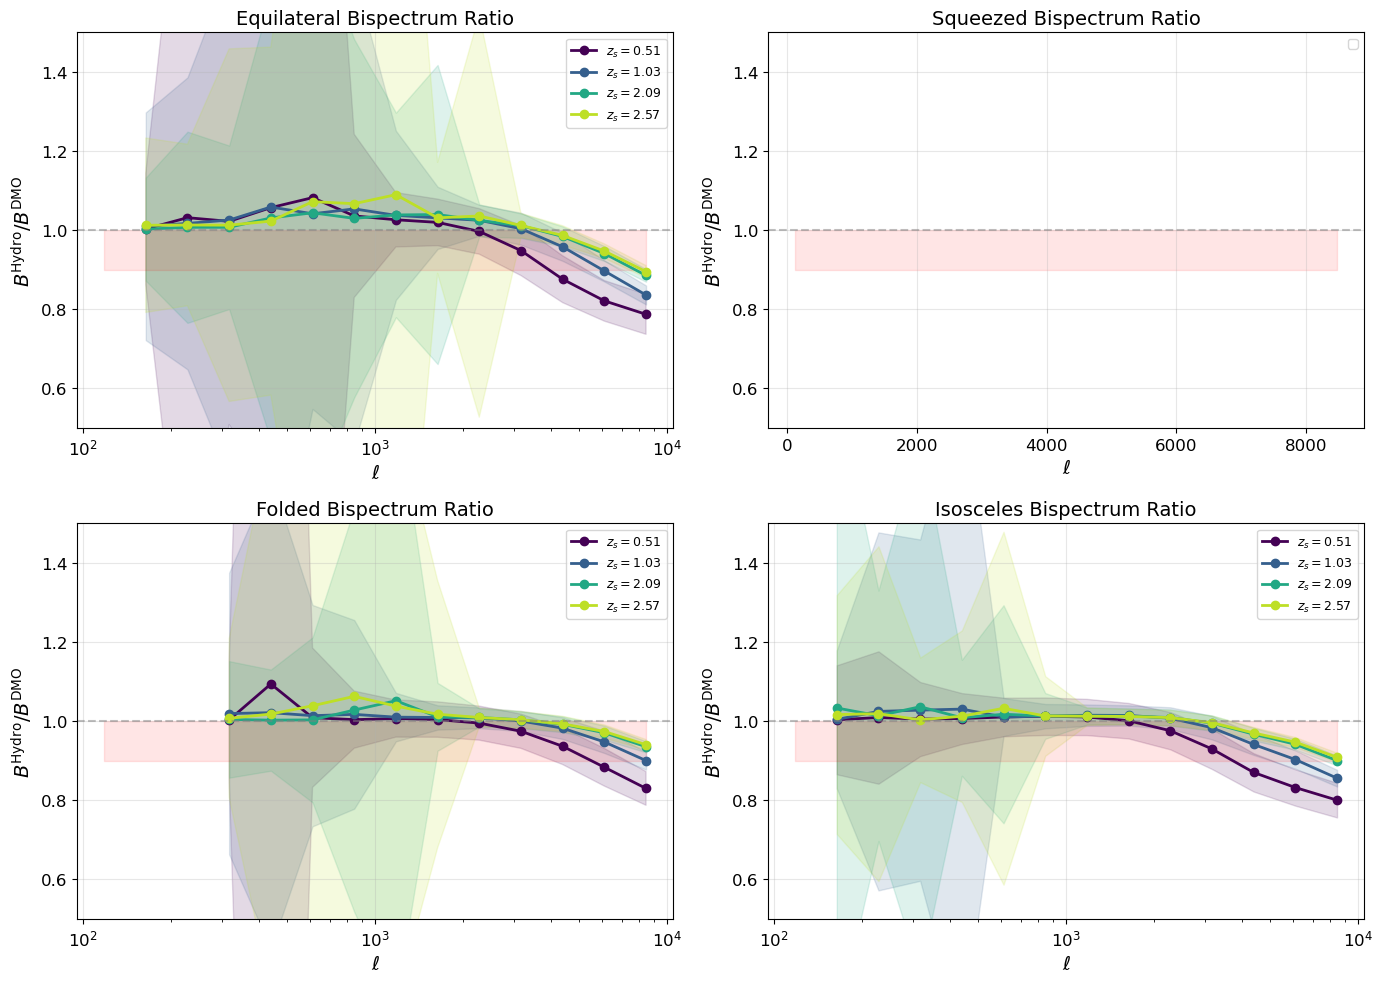

In [52]:
# Bispectrum ratio: Hydro / DMO
bispec_keys = ['bispec_equilateral', 'bispec_squeezed', 'bispec_folded', 'bispec_isosceles']
if (data_dmo is not None and data_hydro is not None and 'bispec_ell' in data_dmo and
    any(k in data_dmo for k in bispec_keys) and any(k in data_hydro for k in bispec_keys)):
    
    ell_bispec = data_dmo['bispec_ell']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    configs = ['equilateral', 'squeezed', 'folded', 'isosceles']
    config_titles = ['Equilateral', 'Squeezed', 'Folded', 'Isosceles']
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(source_z)))
    
    for ax, config, title in zip(axes, configs, config_titles):
        key = f'bispec_{config}'
        if key in data_dmo and key in data_hydro:
            bispec_dmo = data_dmo[key]
            bispec_hydro = data_hydro[key]
            
            for z_idx, (z, color) in enumerate(zip(source_z, colors)):
                # Per-realization ratio to cancel cosmic variance
                with np.errstate(divide='ignore', invalid='ignore'):
                    B_ratio = bispec_hydro[:, z_idx, :] / bispec_dmo[:, z_idx, :]
                    # Mask where values are too small or have opposite signs
                    bad = (np.abs(bispec_dmo[:, z_idx, :]) < 1e-12) | (np.sign(bispec_dmo[:, z_idx, :]) != np.sign(bispec_hydro[:, z_idx, :]))
                    B_ratio[bad] = np.nan
                
                ratio_mean = np.nanmean(B_ratio, axis=0)
                ratio_std = np.nanstd(B_ratio, axis=0)
                
                mask = ~np.isnan(ratio_mean)
                if np.any(mask):
                    ax.semilogx(ell_bispec[mask], ratio_mean[mask], 'o-', color=color, 
                               lw=2, ms=6, label=f'$z_s = {z:.2f}$')
                    ax.fill_between(ell_bispec[mask], (ratio_mean - ratio_std)[mask], 
                                   (ratio_mean + ratio_std)[mask], color=color, alpha=0.15)
            
            ax.axhline(1, color='gray', ls='--', alpha=0.5)
            ax.fill_between([ell_bispec.min(), ell_bispec.max()], 0.9, 1.0, alpha=0.1, color='red')
            ax.set_xlabel(r'$\ell$')
            ax.set_ylabel(r'$B^\text{Hydro}/B^\text{DMO}$')
            ax.set_title(f'{title} Bispectrum Ratio')
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.5, 1.5)
        else:
            ax.text(0.5, 0.5, f'{title} data not available', ha='center', va='center', 
                   transform=ax.transAxes)
            ax.set_title(f'{title} Bispectrum Ratio')
    
    plt.tight_layout()
    plt.show()

else:    print("Bispectrum data not available for both models")

## Summary: Baryonic Effects Across Statistics

The comparison above shows that baryonic physics affects weak lensing statistics in complex, **statistic-dependent** ways:

| Statistic | Typical Effect | Scale/Threshold Dependence |
|-----------|---------------|---------------------------|
| $P(k)$ | 10-30% suppression | Strongest at $k \sim 1-10$ h/Mpc |
| $C_\ell$ | 5-15% suppression | Strongest at $\ell \gtrsim 1000$ |
| Peak counts | Suppression at high $\nu$ | $\nu$-dependent |
| Minima | Smaller effect | Mainly at negative $\nu$ |
| PDF | Modified tails | Both high and low $\nu$ |
| Minkowski | Morphology changes | Threshold-dependent |
| WST | Scale-dependent | Smaller scales more affected |
| Bispectrum | Non-Gaussian effects | Configuration-dependent |

This motivates the **baryonic response formalism**: understanding which halos and radii contribute to these effects allows us to model and correct for baryonic physics in cosmological analyses.